## Libraries

In [309]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import datetime as dt
import unidecode


In [310]:
df_finishers= pd.read_csv("../data/tdf_finishers.csv" , sep=";")
df_stages= pd.read_csv("../data/tdf_stages.csv" , sep=";")

In [311]:
import chardet

with open("../data/tdf_tours.csv", "rb") as f:
    result = chardet.detect(f.read(10000))

print(result)


{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [312]:
df_tours = pd.read_csv("../data/tdf_tours.csv", sep=";", encoding=result['encoding'])


In [313]:
import chardet

with open("../data/tdf_winners.csv", "rb") as f:
    result = chardet.detect(f.read(10000))

print(result)


{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [314]:
df_winners = pd.read_csv("../data/tdf_winners.csv", sep=";", encoding=result['encoding'])

## Data Exploration 

### 1.Finishers

In [315]:
df_finishers.head()

,Year,Rank,Rider,Time,Team
0,1903,1,Maurice Garin (FRA),"94h 33' 14""",La Française
1,1903,2,Lucien Pothier (FRA),"+ 2h 59' 21""",La Française
2,1903,3,Fernand Augereau (FRA),"+ 4h 29' 24""",La Française
3,1903,4,Rodolfo Muller[27] (ITA),"+ 4h 39' 30""",La Française
4,1903,5,Jean Fischer (FRA),"+ 4h 58' 44""",La Française


In [316]:
df_finishers.shape

(9895, 5)

In [317]:
df_finishers.columns.tolist()

['Year', 'Rank', 'Rider', 'Time', 'Team']

In [318]:
df_finishers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    9895 non-null   int64 
 1   Rank    9895 non-null   object
 2   Rider   9895 non-null   object
 3   Time    9622 non-null   object
 4   Team    9591 non-null   object
dtypes: int64(1), object(4)
memory usage: 386.7+ KB


#### Duplicated Values Analysis

In [319]:
duplicates = df_finishers.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


#### Time column cleaning

In [320]:
df_finishers['Time_clean'] = (
    df_finishers['Time']
    .str.replace('+', '', regex=False)
    .str.replace('h', ':')
    .str.replace("'", ':')
    .str.replace('"', '')
    .str.strip()
)
import re

def smart_to_seconds(time_str):
    if pd.isnull(time_str):
        return None
    # Supprimer tout ce qui n'est pas chiffre ou séparateur :
    time_str = re.sub(r"[^\d:]", "", time_str)
    parts = time_str.split(':')
    try:
        if len(parts) == 3:  # hh:mm:ss
            h, m, s = map(int, parts)
            return h * 3600 + m * 60 + s
        elif len(parts) == 2:  # mm:ss
            m, s = map(int, parts)
            return m * 60 + s
        elif len(parts) == 1:  # ss
            return int(parts[0])
    except ValueError:
        return None
    return None

df_finishers['Time_sec'] = df_finishers['Time_clean'].apply(smart_to_seconds)
df_finishers['Rank_temp'] = pd.to_numeric(df_finishers['Rank'], errors='coerce')
winner_time = df_finishers.loc[df_finishers['Rank_temp'] == 1, 'Time_sec'].values[0]

df_finishers['Time(sec)'] = df_finishers.apply(
    lambda row: winner_time + row['Time_sec'] if '+' in str(row['Time']) else row['Time_sec'],
    axis=1
)



In [321]:
df_finishers.head()

,Year,Rank,Rider,Time,Team,Time_clean,Time_sec,Rank_temp,Time(sec)
0,1903,1,Maurice Garin (FRA),"94h 33' 14""",La Française,94: 33: 14,340394.0,1.0,340394.0
1,1903,2,Lucien Pothier (FRA),"+ 2h 59' 21""",La Française,2: 59: 21,10761.0,2.0,351155.0
2,1903,3,Fernand Augereau (FRA),"+ 4h 29' 24""",La Française,4: 29: 24,16164.0,3.0,356558.0
3,1903,4,Rodolfo Muller[27] (ITA),"+ 4h 39' 30""",La Française,4: 39: 30,16770.0,4.0,357164.0
4,1903,5,Jean Fischer (FRA),"+ 4h 58' 44""",La Française,4: 58: 44,17924.0,5.0,358318.0


In [322]:
df_finishers.drop(columns=['Rank_temp','Time','Time_sec','Time_clean'], inplace=True)

In [323]:
df_finishers.head()

,Year,Rank,Rider,Team,Time(sec)
0,1903,1,Maurice Garin (FRA),La Française,340394.0
1,1903,2,Lucien Pothier (FRA),La Française,351155.0
2,1903,3,Fernand Augereau (FRA),La Française,356558.0
3,1903,4,Rodolfo Muller[27] (ITA),La Française,357164.0
4,1903,5,Jean Fischer (FRA),La Française,358318.0


#### Missing Values Analysis

In [324]:
missing_data = df_finishers.isnull().sum()
missing_percent = (missing_data / len(df_finishers)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent (%)': missing_percent
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percent (%)', ascending=False)
print(missing_info)

           Missing_Count  Missing_Percent (%)
Team                 304             3.072259
Time(sec)            273             2.758969


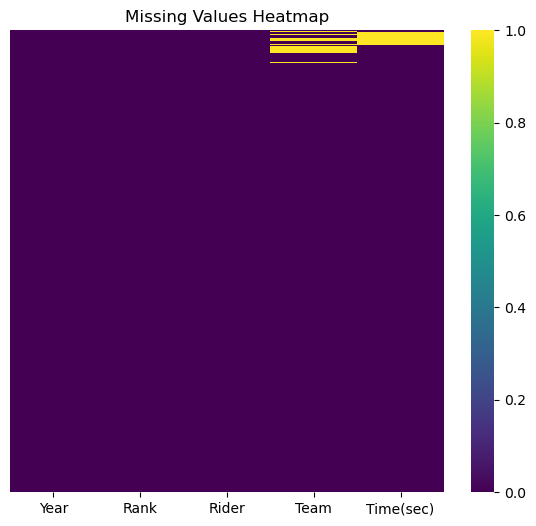

In [325]:
plt.figure(figsize=(7, 6))
sns.heatmap(df_finishers.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [326]:
df_finishers_cleaned = df_finishers.copy()
df_finishers_cleaned['Team'] = df_finishers['Team'].fillna('Unknown')
df_finishers_cleaned['Time(sec)'] = df_finishers['Time(sec)'].fillna(-1)
finishers_cleaned = df_finishers_cleaned.to_excel('../data/clean data/df_finishers_cleaned.xlsx', index=False)


#### Visualisations

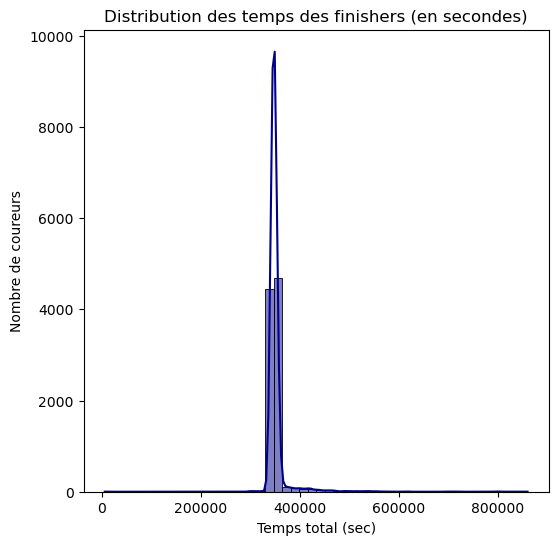

In [327]:
plt.figure(figsize=(6,6))
sns.histplot(df_finishers['Time(sec)'].dropna(), bins=50, kde=True, color='darkblue')
plt.title("Distribution des temps des finishers (en secondes)")
plt.xlabel("Temps total (sec)")
plt.ylabel("Nombre de coureurs")
plt.show()


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\2824146228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=finishers_per_year, x='Year', y='Rider', palette='viridis')


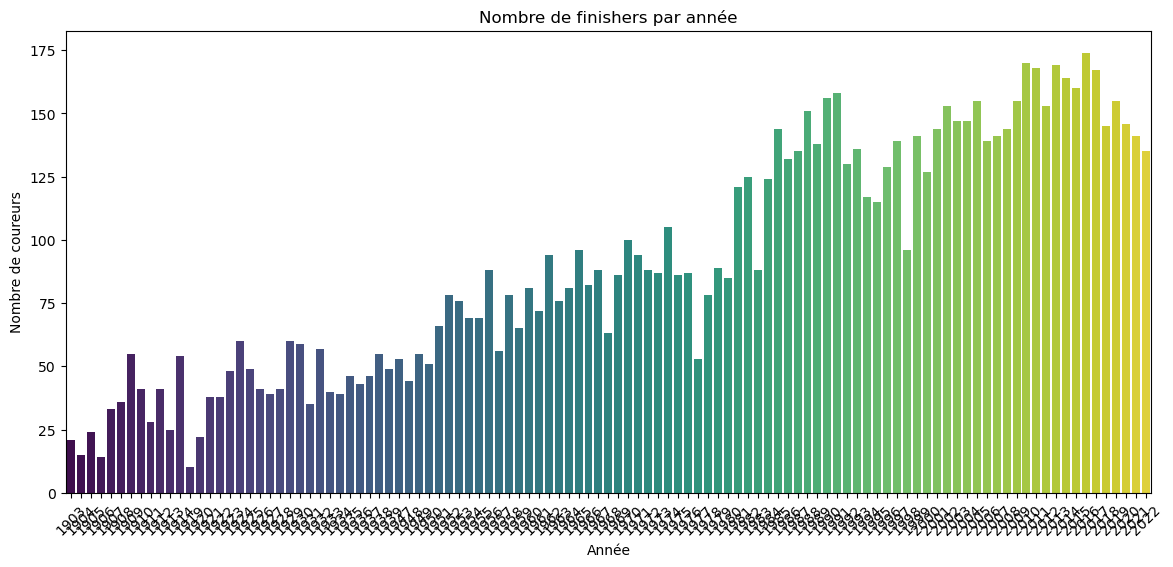

In [328]:
finishers_per_year = df_finishers.groupby('Year')['Rider'].count().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=finishers_per_year, x='Year', y='Rider', palette='viridis')
plt.title("Nombre de finishers par année")
plt.xlabel("Année")
plt.ylabel("Nombre de coureurs")
plt.xticks(rotation=45)
plt.show()


### 2.Stages

In [329]:
df_stages.head()

,Year,Date,Stage,Course,Distance,Type,Winner
0,1903,01/07/1903,1,Paris to Lyon,467 km (290 mi),Plain stage,Maurice Garin (FRA)
1,1903,05/07/1903,2,Lyon to Marseille,374 km (232 mi),Stage with mountain(s),Hippolyte Aucouturier (FRA)
2,1903,08/07/1903,3,Marseille to Toulouse,423 km (263 mi),Plain stage,Hippolyte Aucouturier (FRA)
3,1903,12/07/1903,4,Toulouse to Bordeaux,268 km (167 mi),Plain stage,Charles Laeser (SUI)
4,1903,13/07/1903,5,Bordeaux to Nantes,425 km (264 mi),Plain stage,Maurice Garin (FRA)


In [330]:
df_stages.shape

(2341, 7)

In [331]:
df_stages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Year      2341 non-null   int64 
 1   Date      2341 non-null   object
 2   Stage     2341 non-null   object
 3   Course    2341 non-null   object
 4   Distance  2341 non-null   object
 5   Type      2341 non-null   object
 6   Winner    2341 non-null   object
dtypes: int64(1), object(6)
memory usage: 128.2+ KB


In [332]:
df_stages.columns.tolist()

['Year', 'Date', 'Stage', 'Course', 'Distance', 'Type', 'Winner']

#### Columns Date and distance cleaning

In [333]:
stages_clean = df_stages.copy()
stages_clean['Date'] = pd.to_datetime(df_stages['Date'], dayfirst=True, errors='coerce')
stages_clean['Distance(km)'] = stages_clean['Distance'].str.extract(r'(\d+)\s*km').astype(float)


In [334]:
stages_clean[['Start course', 'End course']] = stages_clean['Course'].str.split(' to ', expand=True)

In [335]:
stages_clean['Winner'] = stages_clean['Winner'].str.replace(r'\[.*?\]', '', regex=True).str.strip()


In [336]:
def create_stage_order(stage_str):
    """
    Create a numeric value for sorting stages in correct order
    Prologue -> 1, 1a -> 2, 1b -> 3, 2 -> 4, etc.
    """
    stage_str = str(stage_str).strip().lower()
    
    if stage_str == 'p':
        return 0  # Prologue comes first
    
    match = re.match(r'^(\d+)([a-z]?)$', stage_str)
    if match:
        base_number = int(match.group(1))
        suffix = match.group(2)
        
        # Convert suffix to numeric offset (a=0.1, b=0.2, etc.)
        suffix_value = 0
        if suffix:
            suffix_value = (ord(suffix) - ord('a') + 1) * 0.1
        
        return base_number + suffix_value
    
    return 999  # Put unrecognized formats at the end

dim_stage['Stage_Order'] = stages_clean['Stage'].apply(create_stage_order)
dim_stage['Stage_Display'] = stages_clean['Stage']  # Keep original for display

print("Stage ordering:")
print(dim_stage[['Stage', 'Stage_Order']].sort_values('Stage_Order').head(15))

Stage ordering:
     Stage  Stage_Order
1138     P          0.0
1192     P          0.0
1217     P          0.0
1921     P          0.0
1942     P          0.0
2005     P          0.0
1879     P          0.0
1900     P          0.0
1837     P          0.0
2068     P          0.0
1815     P          0.0
1771     P          0.0
1793     P          0.0
1750     P          0.0
2110     P          0.0


In [337]:
stages_clean = stages_clean.drop(columns=['Course','Distance','Stage'])


In [338]:
stages_clean.head()

,Year,Date,Type,Winner,Distance(km),Start course,End course
0,1903,1903-07-01,Plain stage,Maurice Garin (FRA),467.0,Paris,Lyon
1,1903,1903-07-05,Stage with mountain(s),Hippolyte Aucouturier (FRA),374.0,Lyon,Marseille
2,1903,1903-07-08,Plain stage,Hippolyte Aucouturier (FRA),423.0,Marseille,Toulouse
3,1903,1903-07-12,Plain stage,Charles Laeser (SUI),268.0,Toulouse,Bordeaux
4,1903,1903-07-13,Plain stage,Maurice Garin (FRA),425.0,Bordeaux,Nantes


#### Duplicated Values Analysis

In [339]:
duplicates = df_stages.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


### Missing Values Analysis

In [340]:
missing_data = df_stages.isnull().sum()
missing_percent = (missing_data / len(df_stages)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent (%)': missing_percent
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percent (%)', ascending=False)
print(missing_info)

Empty DataFrame
Columns: [Missing_Count, Missing_Percent (%)]
Index: []


In [341]:
stages_cleaned = stages_clean.to_excel('../data/clean data/df_stages_cleaned.xlsx', index=False)


#### Visualisations

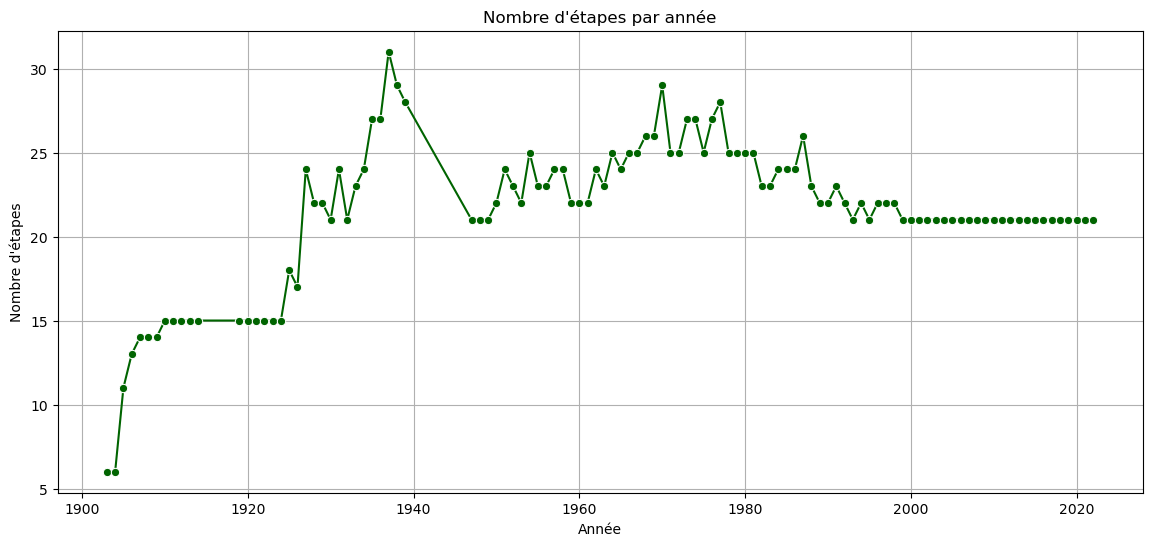

In [342]:
stages_per_year = df_stages.groupby('Year')['Stage'].count().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=stages_per_year, x='Year', y='Stage', marker='o', color='darkgreen')
plt.title("Nombre d'étapes par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'étapes")
plt.grid(True)
plt.show()


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\1807219738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_distance_by_type.values, y=avg_distance_by_type.index, palette='rocket')


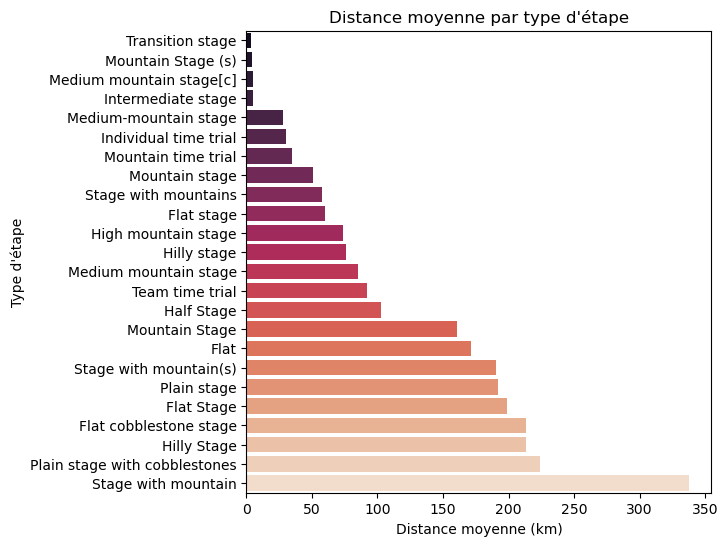

In [343]:

avg_distance_by_type = stages_clean.groupby('Type')['Distance(km)'].mean().sort_values()

plt.figure(figsize=(6,6))
sns.barplot(x=avg_distance_by_type.values, y=avg_distance_by_type.index, palette='rocket')
plt.title("Distance moyenne par type d'étape")
plt.xlabel("Distance moyenne (km)")
plt.ylabel("Type d'étape")
plt.show()


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\4086757665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='mako')


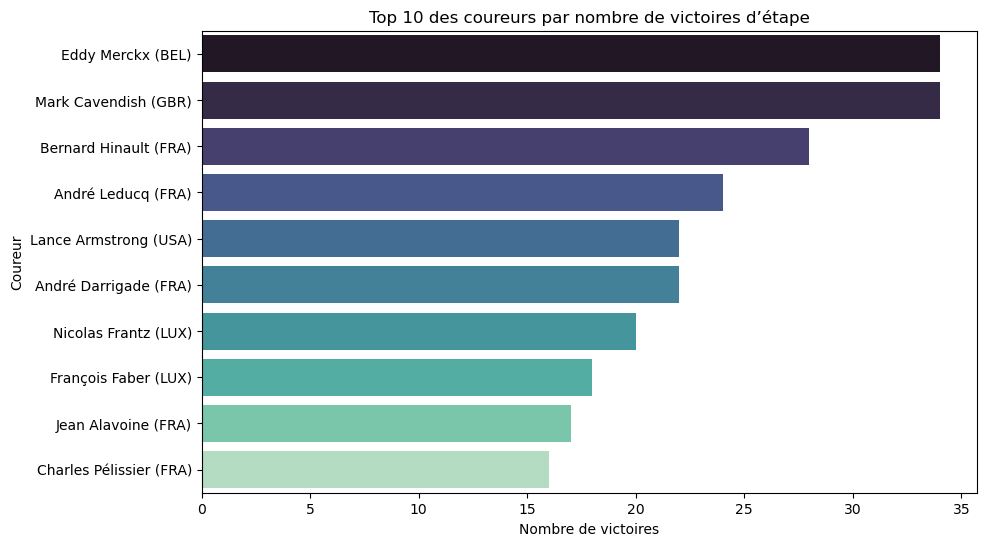

In [344]:
top_winners = stages_clean['Winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_winners.values, y=top_winners.index, palette='mako')
plt.title("Top 10 des coureurs par nombre de victoires d’étape")
plt.xlabel("Nombre de victoires")
plt.ylabel("Coureur")
plt.show()


### 3.Tours

In [345]:
df_tours.head()

,Year,Dates,Stages,Distance,Starters,Finishers
0,1903,1–19 July 1903,6,"2,428 km (1,509 mi)",60,21
1,1904,2–24 July 1904,6,"2,428 km (1,509 mi)",88,15
2,1905,9–30 July 1905,11,"2,994 km (1,860 mi)",60,24
3,1906,4–29 July 1906,13,"4,637 km (2,881 mi)",82,14
4,1907,8 July – 4 August 1907,14,"4,488 km (2,789 mi)",93,33


In [346]:
df_tours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       109 non-null    int64 
 1   Dates      109 non-null    object
 2   Stages     109 non-null    object
 3   Distance   109 non-null    object
 4   Starters   109 non-null    int64 
 5   Finishers  109 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 5.2+ KB


In [347]:
df_tours.shape

(109, 6)

In [348]:
df_tours.columns.tolist()

['Year', 'Dates', 'Stages', 'Distance', 'Starters', 'Finishers']

#### Duplicated Values Analysis

In [349]:
duplicates = df_tours.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


### Missing Values Analysis

In [350]:
missing_data = df_tours.isnull().sum()
missing_percent = (missing_data / len(df_tours)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent (%)': missing_percent
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percent (%)', ascending=False)
print(missing_info)

Empty DataFrame
Columns: [Missing_Count, Missing_Percent (%)]
Index: []


#### Date column clean

In [351]:
import re
from dateutil.parser import parse

def extract_dates(date_str):
    if pd.isnull(date_str): return None, None

    # Cas 1 : "1–19 July 1903"
    match1 = re.match(r'(\d{1,2})–(\d{1,2}) (\w+) (\d{4})', date_str)
    if match1:
        d1, d2, month, year = match1.groups()
        return parse(f"{d1} {month} {year}", dayfirst=True), parse(f"{d2} {month} {year}", dayfirst=True)

    # Cas 2 : "8 July – 4 August 1907"
    match2 = re.match(r'(\d{1,2}) (\w+) – (\d{1,2}) (\w+) (\d{4})', date_str)
    if match2:
        d1, m1, d2, m2, year = match2.groups()
        return parse(f"{d1} {m1} {year}", dayfirst=True), parse(f"{d2} {m2} {year}", dayfirst=True)

    return None, None


In [352]:
tours_clean = df_tours.copy()
# Nettoyage des dates
tours_clean[['Start_Date', 'End_Date']] = df_tours['Dates'].apply(lambda x: pd.Series(extract_dates(x)))
tours_clean['Start_Date'] = pd.to_datetime(tours_clean['Start_Date'], dayfirst=True, errors='coerce')
tours_clean['End_Date'] = pd.to_datetime(tours_clean['End_Date'], dayfirst=True, errors='coerce')

tours_clean['Distance(km)'] = (
    tours_clean['Distance']
    .str.extract(r'([\d,]+)\s*km')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)
tours_clean['Total stages'] = tours_clean['Stages']
tours_clean['Total starters'] = tours_clean['Starters']
tours_clean['Total Finishers'] = tours_clean['Finishers']
import pandas as pd
import re

def extract_stage_count(s):
    if pd.isna(s):
        return None
    s = str(s)
    # Extract the first number before any comma or text
    match = re.search(r'^(\d+)', s)
    if match:
        return int(match.group(1))
    return None

# Apply to your column
tours_clean['Total stages'] = tours_clean['Total stages'].apply(extract_stage_count)

In [353]:
tours_clean.head()

,Year,Dates,Stages,Distance,Starters,Finishers,Start_Date,End_Date,Distance(km),Total stages,Total starters,Total Finishers
0,1903,1–19 July 1903,6,"2,428 km (1,509 mi)",60,21,1903-07-01,1903-07-19,2428.0,6,60,21
1,1904,2–24 July 1904,6,"2,428 km (1,509 mi)",88,15,1904-07-02,1904-07-24,2428.0,6,88,15
2,1905,9–30 July 1905,11,"2,994 km (1,860 mi)",60,24,1905-07-09,1905-07-30,2994.0,11,60,24
3,1906,4–29 July 1906,13,"4,637 km (2,881 mi)",82,14,1906-07-04,1906-07-29,4637.0,13,82,14
4,1907,8 July – 4 August 1907,14,"4,488 km (2,789 mi)",93,33,1907-07-08,1907-08-04,4488.0,14,93,33


In [354]:
tours_clean = tours_clean.drop(columns=['Dates','Distance','Stages','Starters','Finishers'])


In [355]:
tours_cleaned = tours_clean.to_excel('../data/clean data/df_tours_cleaned.xlsx', index=False)


#### Visualisations

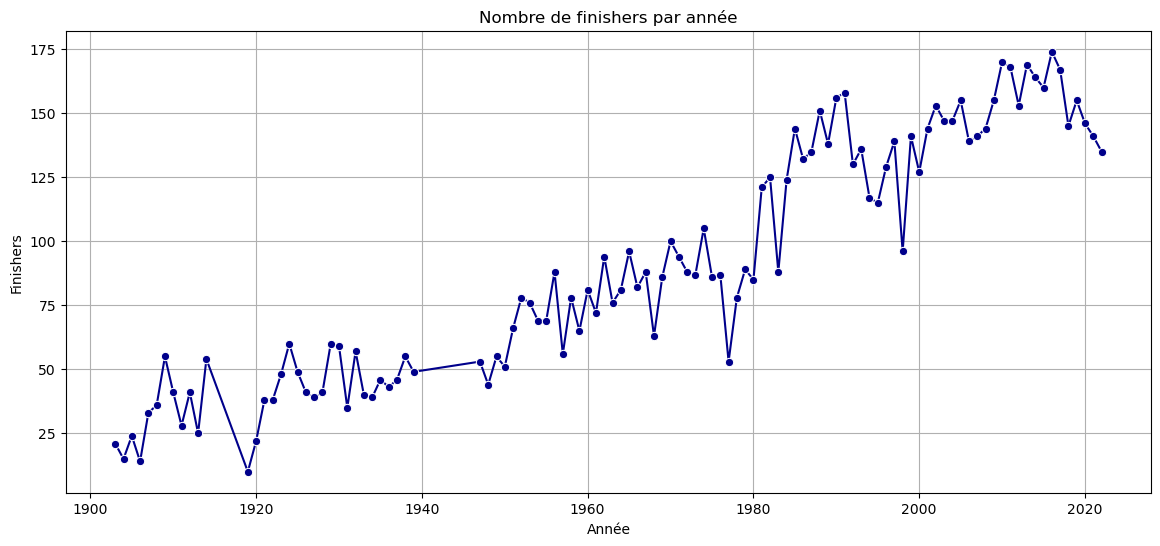

In [356]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_tours, x='Year', y='Finishers', marker='o', color='darkblue')
plt.title("Nombre de finishers par année")
plt.xlabel("Année")
plt.ylabel("Finishers")
plt.grid(True)
plt.show()


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\1721807378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tours, x='Year', y='Distance', palette='viridis')


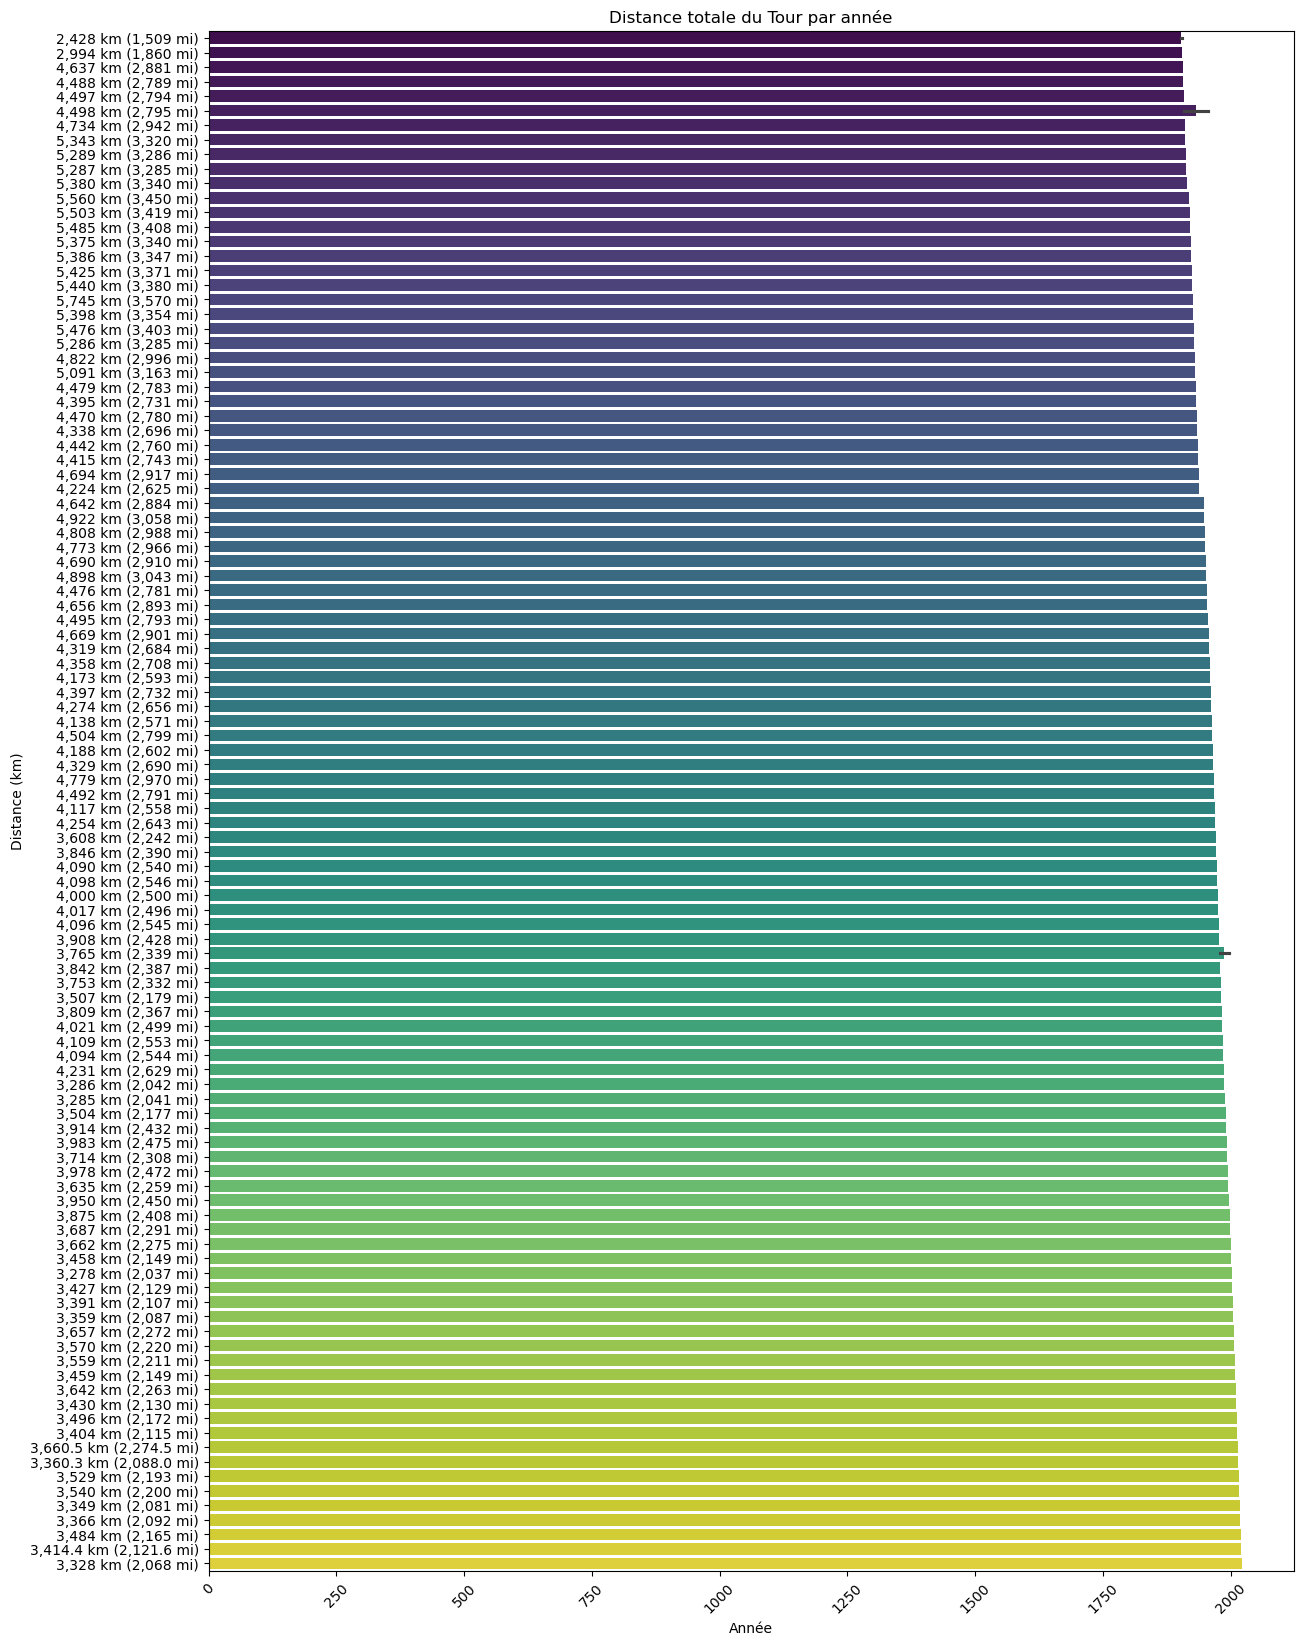

In [357]:
plt.figure(figsize=(14,20))
sns.barplot(data=df_tours, x='Year', y='Distance', palette='viridis')
plt.title("Distance totale du Tour par année")
plt.xlabel("Année")
plt.ylabel("Distance (km)")
plt.xticks(rotation=45)
plt.show()


### 4.Winners

In [358]:
df_winners.head()

,Year,Country,Rider,Team,Time,Margin,Stages Won,Stages Led,Avg Speed,Height,Weight,Born,Died
0,1903,France,Maurice Garin,La Française,"94h 33' 14""","+ 2h 59' 21""",3,6.0,25.7km/h,1.62m,60kg,1871-03-03,19/02/1957
1,1904,France,Henri Cornet,Conte,"96h 05' 55""","+ 2h 16' 14""",1,3.0,25.3km/h,NaN,NaN,1884-08-04,18/03/1941
2,1905,France,Louis Trousselier,Peugeot–Wolber,NaN,NaN,5,10.0,NaN,NaN,NaN,1881-06-29,24/04/1939
3,1906,France,René Pottier,Peugeot–Wolber,NaN,NaN,5,12.0,NaN,NaN,NaN,1879-06-05,25/01/1907
4,1907,France,Lucien Petit-Breton,Peugeot–Wolber,NaN,NaN,2,5.0,NaN,NaN,NaN,1882-10-18,20/12/1917


In [359]:
df_winners.shape

(102, 13)

In [360]:
df_winners.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        102 non-null    int64  
 1   Country     102 non-null    object 
 2   Rider       102 non-null    object 
 3   Team        102 non-null    object 
 4   Time        94 non-null     object 
 5   Margin      94 non-null     object 
 6   Stages Won  102 non-null    int64  
 7   Stages Led  99 non-null     float64
 8   Avg Speed   94 non-null     object 
 9   Height      62 non-null     object 
 10  Weight      63 non-null     object 
 11  Born        102 non-null    object 
 12  Died        56 non-null     object 
dtypes: float64(1), int64(2), object(10)
memory usage: 10.5+ KB


In [361]:
df_winners.columns.tolist()

['Year',
 'Country',
 'Rider',
 'Team',
 'Time',
 'Margin',
 'Stages Won',
 'Stages Led',
 'Avg Speed',
 'Height',
 'Weight',
 'Born',
 'Died']

#### Duplicated Values Analysis

In [362]:
duplicates = df_winners.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


### Missing Values Analysis

In [363]:
missing_data = df_winners.isnull().sum()
missing_percent = (missing_data / len(df_winners)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent (%)': missing_percent
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percent (%)', ascending=False)
print(missing_info)

            Missing_Count  Missing_Percent (%)
Died                   46            45.098039
Height                 40            39.215686
Weight                 39            38.235294
Time                    8             7.843137
Margin                  8             7.843137
Avg Speed               8             7.843137
Stages Led              3             2.941176


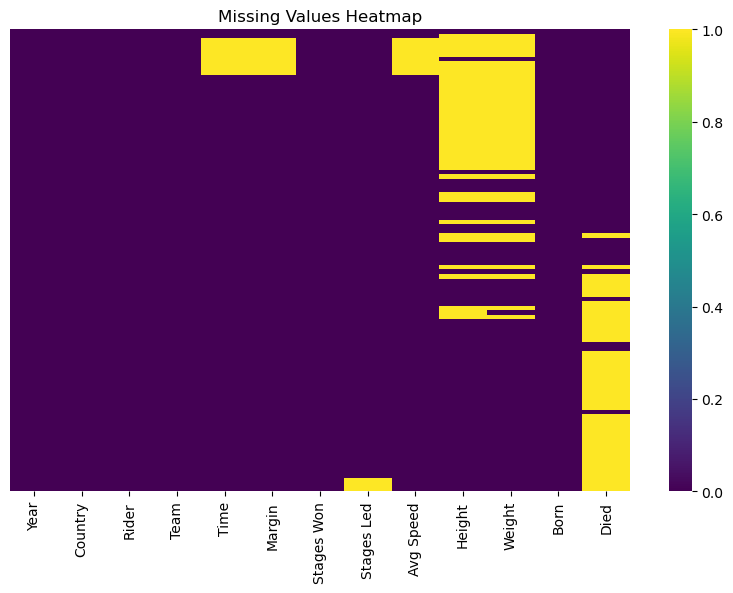

In [364]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_winners.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [365]:
winners_clean = df_winners.copy()

winners_clean = winners_clean.drop(columns=['Died'])
winners_clean.head()

,Year,Country,Rider,Team,Time,Margin,Stages Won,Stages Led,Avg Speed,Height,Weight,Born
0,1903,France,Maurice Garin,La Française,"94h 33' 14""","+ 2h 59' 21""",3,6.0,25.7km/h,1.62m,60kg,1871-03-03
1,1904,France,Henri Cornet,Conte,"96h 05' 55""","+ 2h 16' 14""",1,3.0,25.3km/h,NaN,NaN,1884-08-04
2,1905,France,Louis Trousselier,Peugeot–Wolber,NaN,NaN,5,10.0,NaN,NaN,NaN,1881-06-29
3,1906,France,René Pottier,Peugeot–Wolber,NaN,NaN,5,12.0,NaN,NaN,NaN,1879-06-05
4,1907,France,Lucien Petit-Breton,Peugeot–Wolber,NaN,NaN,2,5.0,NaN,NaN,NaN,1882-10-18


#### Columns cleaning

In [366]:
def clean_time_string(s):
    if pd.isnull(s): return None
    s = s.replace('h', ':').replace("'", ":").replace('"', '').replace('+', '').strip()
    return s

winners_clean['Time_clean'] = winners_clean['Time'].apply(clean_time_string)
winners_clean['Margin_clean'] = winners_clean['Margin'].apply(clean_time_string)
def to_seconds(s):
    if pd.isnull(s): return None
    parts = s.split(':')
    try:
        if len(parts) == 3:
            return int(parts[0])*3600 + int(parts[1])*60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0])*60 + int(parts[1])
    except: return None
    return None

winners_clean['Time(sec)'] = winners_clean['Time_clean'].apply(to_seconds)
winners_clean['Margin(sec)'] = winners_clean['Margin_clean'].apply(to_seconds)


In [367]:
winners_clean.head()

,Year,Country,Rider,Team,Time,Margin,Stages Won,Stages Led,Avg Speed,Height,Weight,Born,Time_clean,Margin_clean,Time(sec),Margin(sec)
0,1903,France,Maurice Garin,La Française,"94h 33' 14""","+ 2h 59' 21""",3,6.0,25.7km/h,1.62m,60kg,1871-03-03,94: 33: 14,2: 59: 21,340394.0,10761.0
1,1904,France,Henri Cornet,Conte,"96h 05' 55""","+ 2h 16' 14""",1,3.0,25.3km/h,NaN,NaN,1884-08-04,96: 05: 55,2: 16: 14,345955.0,8174.0
2,1905,France,Louis Trousselier,Peugeot–Wolber,NaN,NaN,5,10.0,NaN,NaN,NaN,1881-06-29,None,None,NaN,NaN
3,1906,France,René Pottier,Peugeot–Wolber,NaN,NaN,5,12.0,NaN,NaN,NaN,1879-06-05,None,None,NaN,NaN
4,1907,France,Lucien Petit-Breton,Peugeot–Wolber,NaN,NaN,2,5.0,NaN,NaN,NaN,1882-10-18,None,None,NaN,NaN


In [368]:
winners_clean['Height(m)'] = winners_clean['Height'].str.replace('m', '', regex=False).astype(float)
winners_clean['Weight(kg)'] = winners_clean['Weight'].str.replace('kg', '', regex=False).astype(float)
winners_clean['Avg Speed(km/h)'] = winners_clean['Avg Speed'].str.replace('km/h', '', regex=False).astype(float)

# Supprimer les anciennes colonnes
winners_clean = winners_clean.drop(columns=['Height', 'Weight', 'Avg Speed'])

# Vérifier le résultat
winners_clean.head()

,Year,Country,Rider,Team,Time,Margin,Stages Won,Stages Led,Born,Time_clean,Margin_clean,Time(sec),Margin(sec),Height(m),Weight(kg),Avg Speed(km/h)
0,1903,France,Maurice Garin,La Française,"94h 33' 14""","+ 2h 59' 21""",3,6.0,1871-03-03,94: 33: 14,2: 59: 21,340394.0,10761.0,1.62,60.0,25.7
1,1904,France,Henri Cornet,Conte,"96h 05' 55""","+ 2h 16' 14""",1,3.0,1884-08-04,96: 05: 55,2: 16: 14,345955.0,8174.0,NaN,NaN,25.3
2,1905,France,Louis Trousselier,Peugeot–Wolber,NaN,NaN,5,10.0,1881-06-29,None,None,NaN,NaN,NaN,NaN,NaN
3,1906,France,René Pottier,Peugeot–Wolber,NaN,NaN,5,12.0,1879-06-05,None,None,NaN,NaN,NaN,NaN,NaN
4,1907,France,Lucien Petit-Breton,Peugeot–Wolber,NaN,NaN,2,5.0,1882-10-18,None,None,NaN,NaN,NaN,NaN,NaN


In [369]:
winners_clean = winners_clean.drop(columns=['Time','Margin','Time_clean','Margin_clean'])


In [370]:
winners_clean.head()

,Year,Country,Rider,Team,Stages Won,Stages Led,Born,Time(sec),Margin(sec),Height(m),Weight(kg),Avg Speed(km/h)
0,1903,France,Maurice Garin,La Française,3,6.0,1871-03-03,340394.0,10761.0,1.62,60.0,25.7
1,1904,France,Henri Cornet,Conte,1,3.0,1884-08-04,345955.0,8174.0,NaN,NaN,25.3
2,1905,France,Louis Trousselier,Peugeot–Wolber,5,10.0,1881-06-29,NaN,NaN,NaN,NaN,NaN
3,1906,France,René Pottier,Peugeot–Wolber,5,12.0,1879-06-05,NaN,NaN,NaN,NaN,NaN
4,1907,France,Lucien Petit-Breton,Peugeot–Wolber,2,5.0,1882-10-18,NaN,NaN,NaN,NaN,NaN


In [371]:
missing_data = winners_clean.isnull().sum()
missing_data

Year                0
Country             0
Rider               0
Team                0
Stages Won          0
Stages Led          3
Born                0
Time(sec)           8
Margin(sec)        18
Height(m)          40
Weight(kg)         39
Avg Speed(km/h)     8
dtype: int64

In [372]:
# Fill missing 'Stages Led' with 0 (assumes no data = no leadership)
winners_clean['Stages Led'] = winners_clean['Stages Led'].fillna(0)
# Fill missing time and margin with -1 for dashboard filtering
winners_clean['Time(sec)'] = winners_clean['Time(sec)'].fillna(-1)
winners_clean['Margin(sec)'] = winners_clean['Margin(sec)'].fillna(-1)
winners_clean['Avg Speed(km/h)'].fillna(
    winners_clean['Avg Speed(km/h)'].mean(), inplace=True
)
winners_clean['Height(m)'].fillna(
    winners_clean['Height(m)'].median(), inplace=True
)
winners_clean['Weight(kg)'].fillna(
    winners_clean['Weight(kg)'].median(), inplace=True
)


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\1491440860.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  winners_clean['Avg Speed(km/h)'].fillna(
C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\1491440860.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [373]:
missing_data = winners_clean.isnull().sum()
missing_data

Year               0
Country            0
Rider              0
Team               0
Stages Won         0
Stages Led         0
Born               0
Time(sec)          0
Margin(sec)        0
Height(m)          0
Weight(kg)         0
Avg Speed(km/h)    0
dtype: int64

In [374]:
winners_clean.to_excel('../data/clean data/df_winners_clean.xlsx', index=False )


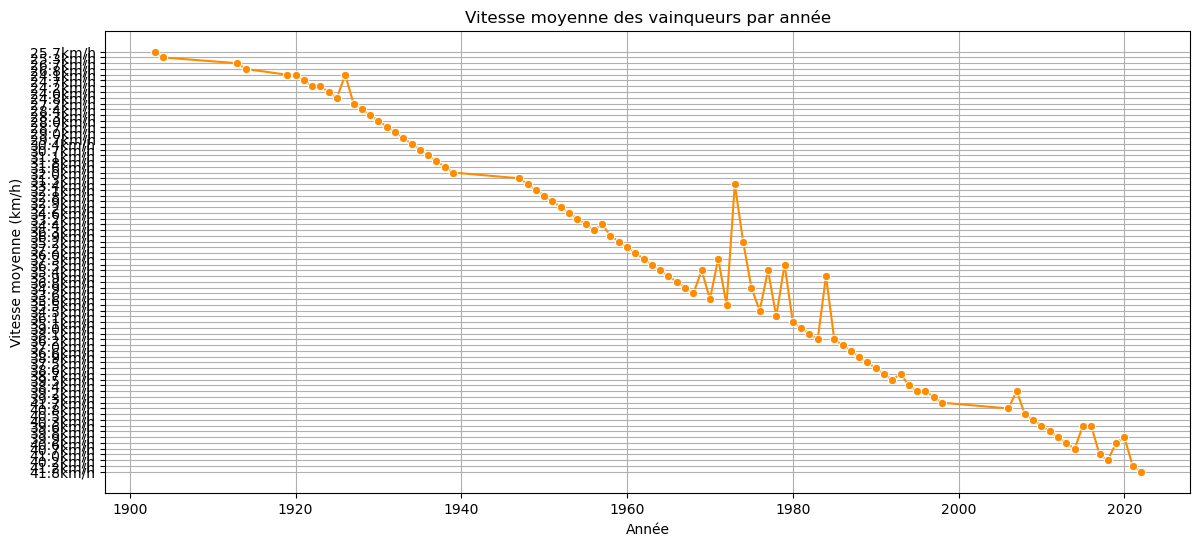

In [375]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_winners, x='Year', y='Avg Speed', marker='o', color='darkorange')
plt.title("Vitesse moyenne des vainqueurs par année")
plt.xlabel("Année")
plt.ylabel("Vitesse moyenne (km/h)")
plt.grid(True)
plt.show()


C:\Users\hajer\AppData\Local\Temp\ipykernel_10340\3815312283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_winners.sort_values('Stages Won', ascending=False).head(10),


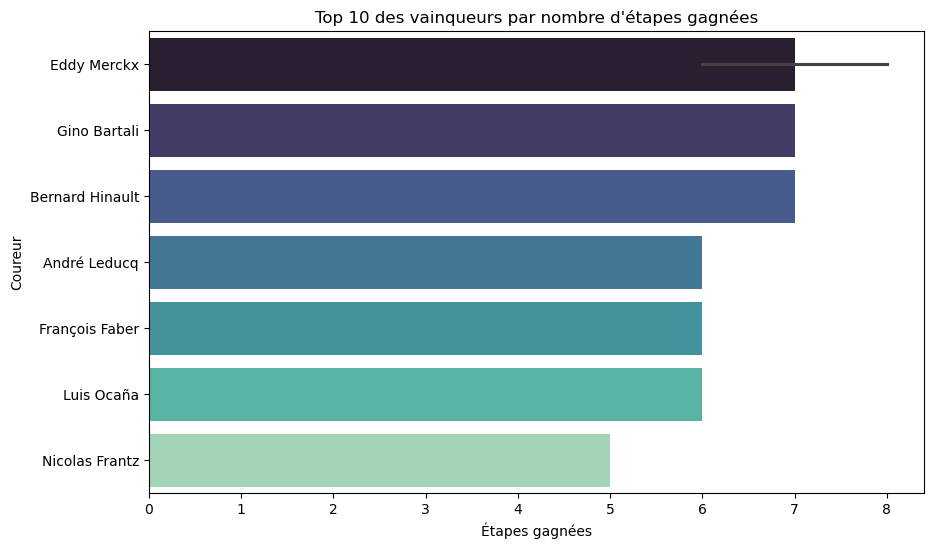

In [376]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_winners.sort_values('Stages Won', ascending=False).head(10),
            x='Stages Won', y='Rider', palette='mako')
plt.title("Top 10 des vainqueurs par nombre d'étapes gagnées")
plt.xlabel("Étapes gagnées")
plt.ylabel("Coureur")
plt.show()


In [377]:
stages_clean.columns.tolist()

['Year',
 'Date',
 'Type',
 'Winner',
 'Distance(km)',
 'Start course',
 'End course']

In [378]:
df_finishers_cleaned.columns.tolist()

['Year', 'Rank', 'Rider', 'Team', 'Time(sec)']

In [379]:
tours_clean.columns.tolist()

['Year',
 'Start_Date',
 'End_Date',
 'Distance(km)',
 'Total stages',
 'Total starters',
 'Total Finishers']

In [380]:
winners_clean.columns.tolist()

['Year',
 'Country',
 'Rider',
 'Team',
 'Stages Won',
 'Stages Led',
 'Born',
 'Time(sec)',
 'Margin(sec)',
 'Height(m)',
 'Weight(kg)',
 'Avg Speed(km/h)']

In [7]:
import pandas as pd
import glob

# Path to your folder containing Excel files
folder_path = "../data/clean data/"

# Get all Excel files in the folder
excel_files = glob.glob(folder_path + "*.xlsx")

# Create a new Excel writer object (output file)
with pd.ExcelWriter(folder_path + "combined_workbook.xlsx", engine="openpyxl") as writer:
    for file in excel_files:
        # Extract just the file name (without path or extension)
        sheet_name = file.split("\\")[-1].split("/")[-1].replace(".xlsx", "")
        
        # Read the Excel file into a DataFrame
        df = pd.read_excel(file)
        
        # Write it to a new sheet
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)  # Excel sheet names must be ≤31 chars
